# 餐厅评分预测与评论分析

## Python 课程大作业完整版本

本 notebook 面向答辩展示，包含数据读取、数据清洗、探索性分析、评论情感分类、评分回归预测、参数调优、新评论预测和结果保存。

## 0. 项目说明

本项目使用餐厅评论样例数据，字段结构参考真实餐厅评论平台，包括用户编号、餐厅编号、总体评分、环境评分、口味评分、服务评分、评论时间和评论内容。由于课程作业重点是完成完整的数据分析与建模流程，因此使用规模适中的样例数据进行实验。

In [3]:
# ========== 0. 导入相关库 ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
try:
    import jieba
except ImportError:
    jieba = None
    print('提示：当前环境未安装 jieba，将使用简单分词；如需更好中文分词，可运行 pip install jieba')
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# 设置中文显示，若本机没有对应字体，图中中文可能显示为方框，但不影响模型运行
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('库导入完成')

d:\Python\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


库导入完成


In [4]:
# ========== 1. 加载餐厅评论数据集 ==========
print('=' * 60)
print('1. 加载餐厅评论数据集')
print('=' * 60)

data_path = 'ratings_sample.csv'
df = pd.read_csv(data_path)

print(f'数据集形状: {df.shape}')
print('字段名称:', list(df.columns))
df.head()

1. 加载餐厅评论数据集
数据集形状: (10000, 8)
字段名称: ['userId', 'restId', 'rating', 'rating_env', 'rating_flavor', 'rating_service', 'timestamp', 'comment']


,userId,restId,rating,rating_env,rating_flavor,rating_service,timestamp,comment
0,406129,118962,3.0,3.0,2.0,3.0,1321953120000,义法蓝带猪排，太大一块。。。吃得好撑，我个人觉得口味一般，不是很好吃，不是很对我胃口，里面的...
1,62776,84536,3.0,2.0,2.0,2.0,1307719620000,希望越大，失望越大。\n一份价钱，一份质量。\n108自助的东西太少了，1个人还是78的比较...
2,380879,208823,4.0,3.0,3.0,3.0,1325675040000,每次都是去饮茶，未吃过饭。D点心做得几好，喜欢它的雀笼点心。服务都算到位，有BB专用餐具。环...
3,34196,22180,3.0,3.0,2.0,2.0,1292847780000,在东门混乱的坏境中这里的环境是好的了\n原来是海天肠粉\n现在全心全意做快餐了\n只是不见的...
4,197287,157892,3.0,3.0,3.0,3.0,1312470900000,NaN


In [5]:
# ========== 2. 数据探索 ==========
print('\n' + '=' * 60)
print('2. 数据探索')
print('=' * 60)

print('数据基本信息:')
print(df.info())

print('\n缺失值统计:')
print(df.isnull().sum())

print('\n评分字段描述统计:')
print(df[['rating', 'rating_env', 'rating_flavor', 'rating_service']].describe())


2. 数据探索
数据基本信息:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   userId          10000 non-null  int64  
 1   restId          10000 non-null  int64  
 2   rating          10000 non-null  float64
 3   rating_env      8946 non-null   float64
 4   rating_flavor   9009 non-null   float64
 5   rating_service  8946 non-null   float64
 6   timestamp       10000 non-null  int64  
 7   comment         9037 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 4.2 MB
None

缺失值统计:
userId               0
restId               0
rating               0
rating_env        1054
rating_flavor      991
rating_service    1054
timestamp            0
comment            963
dtype: int64

评分字段描述统计:
             rating   rating_env  rating_flavor  rating_service
count  10000.000000  8946.000000    9009.000000     8946.000000
mean       3.595800     2.8031

In [6]:
# ========== 3. 数据清洗 ==========
print('\n' + '=' * 60)
print('3. 数据清洗')
print('=' * 60)

df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip()

# 数值字段转换
score_cols = ['rating', 'rating_env', 'rating_flavor', 'rating_service']
for col in score_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 删除关键字段缺失的数据
before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['rating', 'comment'])

# 分项评分缺失值用均值填充
for col in ['rating_env', 'rating_flavor', 'rating_service']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# 去除空评论

df_clean['comment'] = df_clean['comment'].astype(str).str.strip()
df_clean = df_clean[df_clean['comment'].str.len() > 0]

after_rows = len(df_clean)
print(f'清洗前样本数: {before_rows}')
print(f'清洗后样本数: {after_rows}')
print(f'删除样本数: {before_rows - after_rows}')

df_clean.head()


3. 数据清洗
清洗前样本数: 10000
清洗后样本数: 9037
删除样本数: 963


,userId,restId,rating,rating_env,rating_flavor,rating_service,timestamp,comment
0,406129,118962,3.0,3.0,2.0,3.0,1321953120000,义法蓝带猪排，太大一块。。。吃得好撑，我个人觉得口味一般，不是很好吃，不是很对我胃口，里面的...
1,62776,84536,3.0,2.0,2.0,2.0,1307719620000,希望越大，失望越大。\n一份价钱，一份质量。\n108自助的东西太少了，1个人还是78的比较...
2,380879,208823,4.0,3.0,3.0,3.0,1325675040000,每次都是去饮茶，未吃过饭。D点心做得几好，喜欢它的雀笼点心。服务都算到位，有BB专用餐具。环...
3,34196,22180,3.0,3.0,2.0,2.0,1292847780000,在东门混乱的坏境中这里的环境是好的了\n原来是海天肠粉\n现在全心全意做快餐了\n只是不见的...
5,42241,213829,3.0,3.0,2.0,3.0,1303279740000,记得来这里是因为比乐士人太多排不上了呃。。\n所以就来了这里 本来想点自助。。BF说想吃干锅...


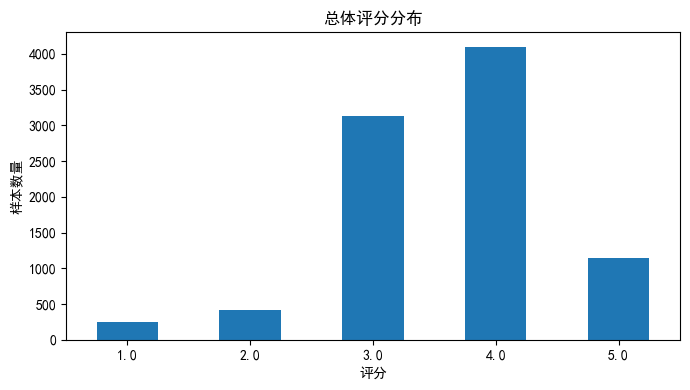

In [7]:
# ========== 4. 可视化：评分分布 ==========
plt.figure(figsize=(7, 4))
df_clean['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('总体评分分布')
plt.xlabel('评分')
plt.ylabel('样本数量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

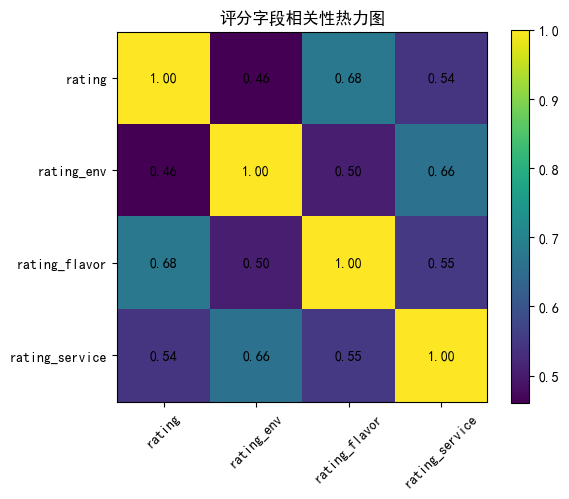

,rating,rating_env,rating_flavor,rating_service
rating,1.000000,0.459771,0.675632,0.542447
rating_env,0.459771,1.000000,0.504438,0.662179
rating_flavor,0.675632,0.504438,1.000000,0.549650
rating_service,0.542447,0.662179,0.549650,1.000000


In [8]:
# ========== 5. 可视化：分项评分相关性 ==========
corr = df_clean[['rating', 'rating_env', 'rating_flavor', 'rating_service']].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('评分字段相关性热力图')

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.tight_layout()
plt.show()

corr

分类任务样本数: 5909
label_name
好评    5241
差评     668
Name: count, dtype: int64


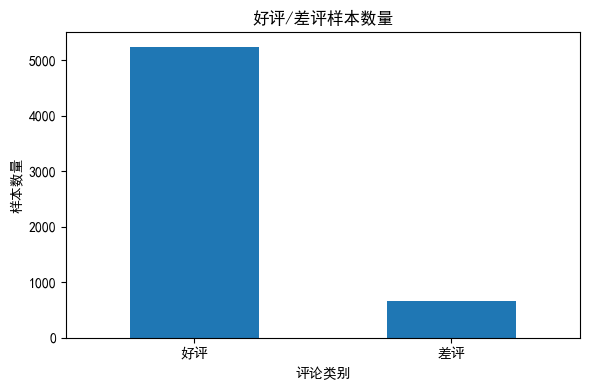

In [9]:
# ========== 6. 构造好评/差评标签 ==========
# 说明：评分大于等于4定义为好评，评分小于等于2定义为差评，3分作为中评不参与二分类训练

df_cls = df_clean[df_clean['rating'] != 3].copy()
df_cls['label'] = df_cls['rating'].apply(lambda x: 1 if x >= 4 else 0)

def label_name(x):
    return '好评' if x == 1 else '差评'

df_cls['label_name'] = df_cls['label'].apply(label_name)

print('分类任务样本数:', len(df_cls))
print(df_cls['label_name'].value_counts())

plt.figure(figsize=(6, 4))
df_cls['label_name'].value_counts().plot(kind='bar')
plt.title('好评/差评样本数量')
plt.xlabel('评论类别')
plt.ylabel('样本数量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ========== 7. 中文文本清洗与分词 ==========
# 加载停用词表
STOPWORDS_PATH = 'stopwords.txt'  
try:
    with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
        stopwords_set = set(line.strip() for line in f if line.strip())
except FileNotFoundError:
    print(f"警告：未找到停用词文件 {STOPWORDS_PATH}，将不使用停用词过滤")
    stopwords_set = set()

def clean_text(text):
    original_text = str(text)
    # 保留中文、字母、数字，其余转为空格
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9]', ' ', original_text)
    
    if jieba is not None:
        words = jieba.lcut(text)
    else:
        # 未安装 jieba 时的备用方案
        key_words = [
            '好吃', '不错', '推荐', '舒服', '分量足', '口味不错', '环境好', '服务好', '服务热情',
            '新鲜', '满意', '美味', '实惠', '干净', '喜欢', '热情',
            '难吃', '失望', '服务差', '环境差', '不推荐', '踩雷', '上菜慢', '排队久',
            '价格贵', '不新鲜', '太咸', '冷淡', '吵闹', '口味一般', '服务不主动', '一般'
        ]
        words = text.split()
        words += [kw for kw in key_words if kw in original_text]
    
    # 过滤：长度>1，且不是停用词，且不是纯阿拉伯数字
    filtered_words = []
    for w in words:
        w_clean = w.strip()
        if len(w_clean) <= 1:
            continue
        # 过滤停用词
        if w_clean in stopwords_set:
            continue
        # 过滤纯阿拉伯数字（例如 123, 0, 999）
        if w_clean.isdigit():
            continue
        filtered_words.append(w_clean)
    
    return ' '.join(filtered_words)

# 后续调用不变
df_cls['comment_cut'] = df_cls['comment'].apply(clean_text)
df_clean['comment_cut'] = df_clean['comment'].apply(clean_text)

print('分词示例:')
df_cls[['comment', 'comment_cut', 'label_name']].head(10)

分词示例:


,comment,comment_cut,label_name
2,每次都是去饮茶，未吃过饭。D点心做得几好，喜欢它的雀笼点心。服务都算到位，有BB专用餐具。环...,饮茶 吃过饭 点心 几好 喜欢 点心 到位 BB 专用 餐具 成日 等位,好评
6,都挺好的…价位正规…我要了个香肠和鸡柳的…都挺好的…但建议要鸡柳的性价比更高…等电影时可以吃...,价位 正规 我要 香肠 更高 电影 吃点 套餐,好评
9,首先得说这家店的地理位置还是不错的，开在地铁口，刚开的时候生意很好。东西也算是多的，不过也不...,地理位置 不错 地铁口 刚开 生意 算上 LOCK 杯子 几年 用到 外表 磨得 厉害 之外...,好评
10,也有好几年没来过这家东西吃饭了，不知道什么时候改名叫粤西楼了。房间可能一两年前重新装修过，今...,好几年 没来 吃饭 改名 粤西 一两年 廉江 对外 方正 湛江 还过得去 没窗 房忘 预定 ...,好评
14,这边带给我们的不仅仅是一份饭，是带着很多回忆的地方\n毕业那天，大学城的最后一餐吃的就是fr...,带给 回忆 毕业 大学城 一餐 friends 羡慕 学弟 学妹 松江 美味 friends...,好评
16,跟黄河路355号是一幢楼~这家在路的拐角，拐弯就是Odeli啦~\n生意超级好啊，不管是6点...,黄河路 一幢 拐角 拐弯 Odeli 生意 喜欢 珍珠 布丁 奶茶 某人 布丁 杯子 布丁 ...,好评
17,买个蛋糕连塑料袋都没有，下雨天蛋糕盒子全部湿掉了，服务人员态度冷漠，说没有就是没有。也没帮助...,买个 蛋糕 塑料袋 下雨天 蛋糕 盒子 湿掉 人员 冷漠 办法 事情 蛋糕 塑料袋 太过分,差评
19,还是很好找的 但是因为有大叔给他的斗满江几个大字挡住了 里边的装修风格特别好 灰常的喜欢 去...,好找 大叔 满江 大字 挡住 里边 灰常 喜欢 开业 聊天 不错 没少花,好评
20,免费抽电影票的活动骗人的，今天晚上顺路去了双井的全城热恋，三层，服务台小姐说没这个活动，活动...,电影票 活动 骗人 顺路去 双井 全城 热恋 服务台 小姐 活动 活动 两天 真假,差评
21,下班前买了个浓巧克力打算晚饭后吃的，巧克力酱很浓郁，中间有奶油，布丁的味道，放在微波炉里赚了...,下班 巧克力 打算 晚饭 巧克力 浓郁 奶油 布丁 味道 放在 微波炉 巧克力 化开 味道 ...,好评


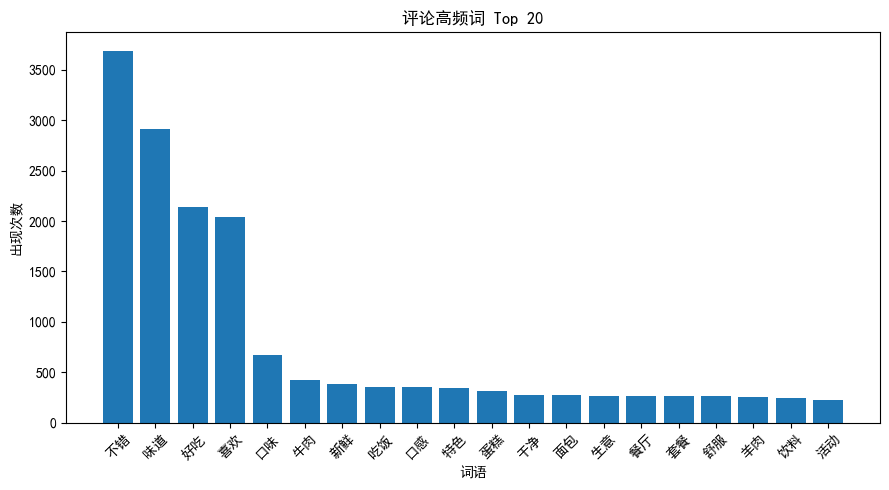

,词语,出现次数
0,不错,3687
1,味道,2909
2,好吃,2142
3,喜欢,2042
4,口味,671
5,牛肉,422
6,新鲜,379
7,吃饭,352
8,口感,351
9,特色,344


In [15]:
# ========== 8. 高频词统计 ==========
from collections import Counter

all_words = ' '.join(df_cls['comment_cut']).split()
word_count = Counter(all_words)
top_words = pd.DataFrame(word_count.most_common(20), columns=['词语', '出现次数'])

plt.figure(figsize=(9, 5))
plt.bar(top_words['词语'], top_words['出现次数'])
plt.title('评论高频词 Top 20')
plt.xlabel('词语')
plt.ylabel('出现次数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_words

In [16]:
# ========== 9. 划分分类任务训练集和测试集 ==========
X = df_cls['comment_cut']
y = df_cls['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('训练集样本数:', len(X_train))
print('测试集样本数:', len(X_test))

训练集样本数: 4727
测试集样本数: 1182


In [17]:
# ========== 10. 基线分类模型：TF-IDF + 逻辑回归 ==========
clf_base = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=2, max_df=0.85)),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0))
])

clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)

print('基线模型准确率:', round(accuracy_score(y_test, y_pred_base), 4))
print('\n分类报告:')
print(classification_report(y_test, y_pred_base, target_names=['差评', '好评']))

基线模型准确率: 0.8883

分类报告:
              precision    recall  f1-score   support

          差评       0.51      0.64      0.57       134
          好评       0.95      0.92      0.94      1048

    accuracy                           0.89      1182
   macro avg       0.73      0.78      0.75      1182
weighted avg       0.90      0.89      0.89      1182



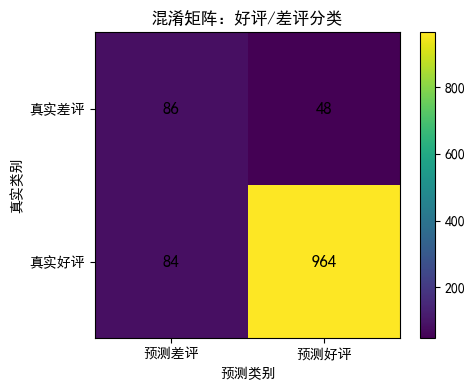

混淆矩阵数值:
[[ 86  48]
 [ 84 964]]


In [18]:
# ========== 11. 混淆矩阵可视化 ==========
cm = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title('混淆矩阵：好评/差评分类')
plt.colorbar()
plt.xticks([0, 1], ['预测差评', '预测好评'])
plt.yticks([0, 1], ['真实差评', '真实好评'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)

plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.tight_layout()
plt.show()

print('混淆矩阵数值:')
print(cm)

In [19]:
# ========== 12. 参数调优：寻找更合适的 C 值 ==========
# C 是逻辑回归中的正则化参数。C 越小，正则化越强；C 越大，正则化越弱。

param_grid = {
    'tfidf__max_features': [3000, 5000],
    'lr__C': [0.1, 1, 10]
}

grid_search = GridSearchCV(
    clf_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print('最佳参数:', grid_search.best_params_)
print('交叉验证最佳准确率:', round(grid_search.best_score_, 4))

best_clf = grid_search.best_estimator_
y_pred_best = best_clf.predict(X_test)
print('测试集准确率:', round(accuracy_score(y_test, y_pred_best), 4))
print('\n最佳模型分类报告:')
print(classification_report(y_test, y_pred_best, target_names=['差评', '好评']))

最佳参数: {'lr__C': 10, 'tfidf__max_features': 5000}
交叉验证最佳准确率: 0.9086
测试集准确率: 0.9044

最佳模型分类报告:
              precision    recall  f1-score   support

          差评       0.58      0.57      0.58       134
          好评       0.95      0.95      0.95      1048

    accuracy                           0.90      1182
   macro avg       0.76      0.76      0.76      1182
weighted avg       0.90      0.90      0.90      1182



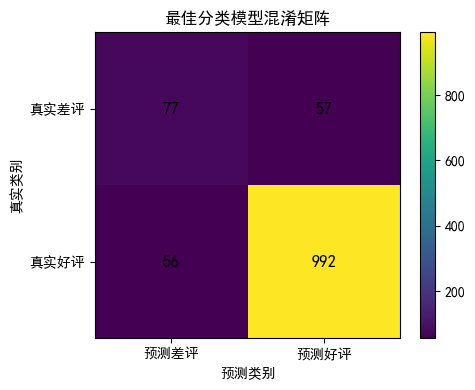

array([[ 77,  57],
       [ 56, 992]])

In [20]:
# ========== 13. 最佳模型混淆矩阵 ==========
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
plt.imshow(cm_best, interpolation='nearest')
plt.title('最佳分类模型混淆矩阵')
plt.colorbar()
plt.xticks([0, 1], ['预测差评', '预测好评'])
plt.yticks([0, 1], ['真实差评', '真实好评'])

for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, cm_best[i, j], ha='center', va='center', fontsize=12)

plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.tight_layout()
plt.show()

cm_best

In [21]:
# ========== 14. 查看对分类影响较大的词 ==========
# 逻辑回归系数为正，说明更倾向于好评；系数为负，说明更倾向于差评

tfidf = best_clf.named_steps['tfidf']
lr = best_clf.named_steps['lr']
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]

top_positive = pd.DataFrame({
    '词语': feature_names[np.argsort(coefs)[-15:][::-1]],
    '系数': np.sort(coefs)[-15:][::-1]
})

top_negative = pd.DataFrame({
    '词语': feature_names[np.argsort(coefs)[:15]],
    '系数': np.sort(coefs)[:15]
})

print('更倾向于好评的词:')
display(top_positive)
print('更倾向于差评的词:')
display(top_negative)

更倾向于好评的词:


,词语,系数
0,不错,13.542513
1,喜欢,11.010071
2,豆腐,4.581332
3,小贵,4.464692
4,美味,4.441974
5,划算,4.212687
6,很香,3.604733
7,入味,3.503240
8,聚会,3.429710
9,挺不错,3.341773


更倾向于差评的词:


,词语,系数
0,难吃,-10.810423
1,很差,-7.433470
2,后悔,-7.021042
3,太差,-6.913642
4,再也不会,-5.937555
5,不值,-5.881336
6,整天,-5.803990
7,最差,-5.679987
8,老板娘,-5.673176
9,再也,-5.548035


In [22]:
# ========== 15. 评分预测模型：TF-IDF + 分项评分 + 随机森林回归 ==========
# 回归任务目标：预测总体评分 rating

X_reg = df_clean[['comment_cut', 'rating_env', 'rating_flavor', 'rating_service']]
y_reg = df_clean['rating']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

preprocess_reg = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=5000, min_df=2, max_df=0.85), 'comment_cut'),
    ('num', StandardScaler(), ['rating_env', 'rating_flavor', 'rating_service'])
])

reg_model = Pipeline([
    ('preprocess', preprocess_reg),
    ('regressor', RandomForestRegressor(
        n_estimators=80,
        max_depth=12,
        random_state=42,
        n_jobs=1
    ))
])

reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print('评分预测模型评价结果:')
print('MAE 平均绝对误差:', round(mae, 4))
print('RMSE 均方根误差:', round(rmse, 4))
print('R2 决定系数:', round(r2, 4))

评分预测模型评价结果:
MAE 平均绝对误差: 0.4215
RMSE 均方根误差: 0.5735
R2 决定系数: 0.5443


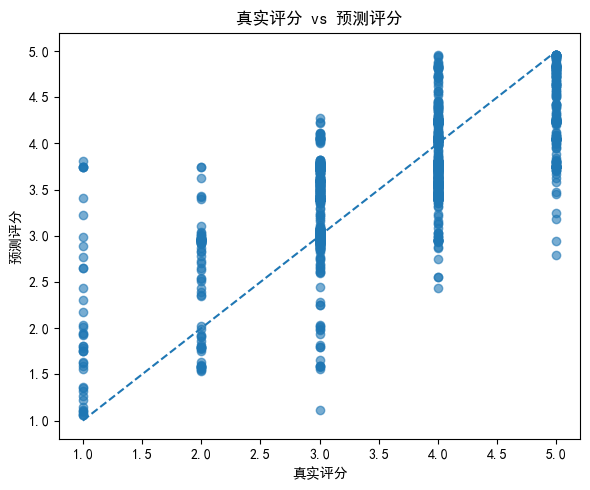

,comment_cut,rating_env,rating_flavor,rating_service,真实评分,预测评分
2134,三文鱼 刺身 芥末 章鱼 摩托罗拉 三文鱼 刺身 芥末 章鱼 章鱼 生菜 榨菜 摩托罗拉 好...,3.000000,4.00000,3.00000,4.0,4.06
1470,探望病人 打算 吃饭 非要 位子 听说 常吃 味道 不错 时分 大厅 满座 包房 东道主 我...,3.000000,3.00000,3.00000,4.0,3.78
5287,菜色 味道 不错 不用说 也许 白天 更好 婚宴 路标 可难 世茂 滨江 再往 右手边 小牌...,4.000000,3.00000,4.00000,4.0,3.80
2346,天气 爬山 举手 恶劣 天气 山沟沟 景点 先乘 一段 小巴 短驳 车到 山里 徒步 步行 ...,2.800565,3.07006,2.76665,3.0,3.64
6291,不错 优雅 换菜式 味道 不错 周到 弹钢琴 顾客 欣赏 自来 形容 讲究 写意 中国 招牌 体现,4.000000,3.00000,4.00000,4.0,3.77
9019,空间 局促 上班 带走 饮品 甜点 还好 喝喝 不错 敬业,2.000000,4.00000,3.00000,4.0,4.05
9197,电影 前去 小资 脆皮 好吃 很香 厚实 冰激凌 口味 醇厚 喜欢 奶油 裱花 舍不得 嘻嘻,2.000000,3.00000,3.00000,4.0,3.75
8687,偶然 猫眼 毕圣客 没法 金枪鱼 沙拉 奶油 蘑菇 不错 一款 牛乃批 怀念,3.000000,3.00000,2.00000,4.0,3.60
9187,湘园 不给力 平安夜 靠窗 位子 椅子 狭窄 坐下 舒服 香锅 牛蛙 几块 牛蛙 很碎 牛蛙...,2.000000,2.00000,2.00000,2.0,2.92
4945,一口气 三杯 竹蔗 清肝 酸梅汤 清肝 龇牙咧嘴 过程 好玩 竹蔗 甘蔗汁 味道 经典 酸梅...,4.000000,4.00000,4.00000,4.0,4.29


In [23]:
# ========== 16. 可视化：真实评分 vs 预测评分 ==========
plt.figure(figsize=(6, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([1, 5], [1, 5], linestyle='--')
plt.title('真实评分 vs 预测评分')
plt.xlabel('真实评分')
plt.ylabel('预测评分')
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.tight_layout()
plt.show()

reg_result = X_test_reg.copy()
reg_result['真实评分'] = y_test_reg.values
reg_result['预测评分'] = np.round(y_pred_reg, 2)
reg_result.head(10)

In [24]:
# ========== 17. 新评论预测演示 ==========
def predict_new_comment(comment):
    comment_cut = clean_text(comment)
    pred_label = best_clf.predict([comment_cut])[0]
    proba = best_clf.predict_proba([comment_cut])[0]
    result = '好评' if pred_label == 1 else '差评'
    return result, proba

new_comments = [
    '这家店味道很好，服务态度也不错，下次还会再来。',
    '菜很难吃，服务态度也不好，等了很久，非常失望。',
    '环境不错，但是上菜速度比较慢，味道一般。'
]

for c in new_comments:
    result, proba = predict_new_comment(c)
    print('评论:', c)
    print('预测结果:', result)
    print('差评概率:', round(proba[0], 4), '好评概率:', round(proba[1], 4))
    print('-' * 60)

评论: 这家店味道很好，服务态度也不错，下次还会再来。
预测结果: 好评
差评概率: 0.0 好评概率: 1.0
------------------------------------------------------------
评论: 菜很难吃，服务态度也不好，等了很久，非常失望。
预测结果: 差评
差评概率: 1.0 好评概率: 0.0
------------------------------------------------------------
评论: 环境不错，但是上菜速度比较慢，味道一般。
预测结果: 好评
差评概率: 0.0783 好评概率: 0.9217
------------------------------------------------------------


In [25]:
# ========== 18. 保存结果 ==========
cls_result = pd.DataFrame({
    '评论分词': X_test.values,
    '真实标签': y_test.values,
    '预测标签': y_pred_best
})
cls_result['真实标签'] = cls_result['真实标签'].map({0: '差评', 1: '好评'})
cls_result['预测标签'] = cls_result['预测标签'].map({0: '差评', 1: '好评'})

cls_result.to_csv('classification_prediction_result.csv', index=False, encoding='utf-8-sig')
reg_result.to_csv('rating_regression_prediction_result.csv', index=False, encoding='utf-8-sig')

print('分类预测结果已保存: classification_prediction_result.csv')
print('评分预测结果已保存: rating_regression_prediction_result.csv')

分类预测结果已保存: classification_prediction_result.csv
评分预测结果已保存: rating_regression_prediction_result.csv


## 19. 项目总结

本项目完成了餐厅评论数据的读取、清洗、探索性分析、文本分词、TF-IDF 特征提取、好评/差评分类、参数调优和总体评分预测。分类任务中使用逻辑回归作为基础模型，并通过网格搜索寻找较优的 C 值；回归任务中结合评论文本和分项评分，使用随机森林模型预测总体评分。

项目不足：数据规模相对有限，且样例数据和真实平台数据仍存在差距；模型主要使用传统机器学习方法，对深层语义理解能力有限。后续可以扩大真实评论数据规模，并尝试 Word2Vec、BERT 等模型进一步提升效果。